In [2]:
# Import Required Libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [3]:
# Load Dataset

df = pd.read_csv("data.csv")

# Display first five rows
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nInformation")
df.info()

Shape of Dataset: (3650, 2)

Column Names
Index(['Date', 'Temp'], dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [5]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [6]:
print(df.isnull().sum())

Date    0
Temp    0
dtype: int64


In [7]:
# Convert Date to Datetime

df['Date'] = pd.to_datetime(df['Date'])

# Set Date as Index

df.set_index('Date', inplace=True)

df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [8]:
df

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


In [9]:
print("Starting Date :", df.index.min())
print("Ending Date   :", df.index.max())

print("\nTotal Observations :", len(df))

Starting Date : 1981-01-01 00:00:00
Ending Date   : 1990-12-31 00:00:00

Total Observations : 3650


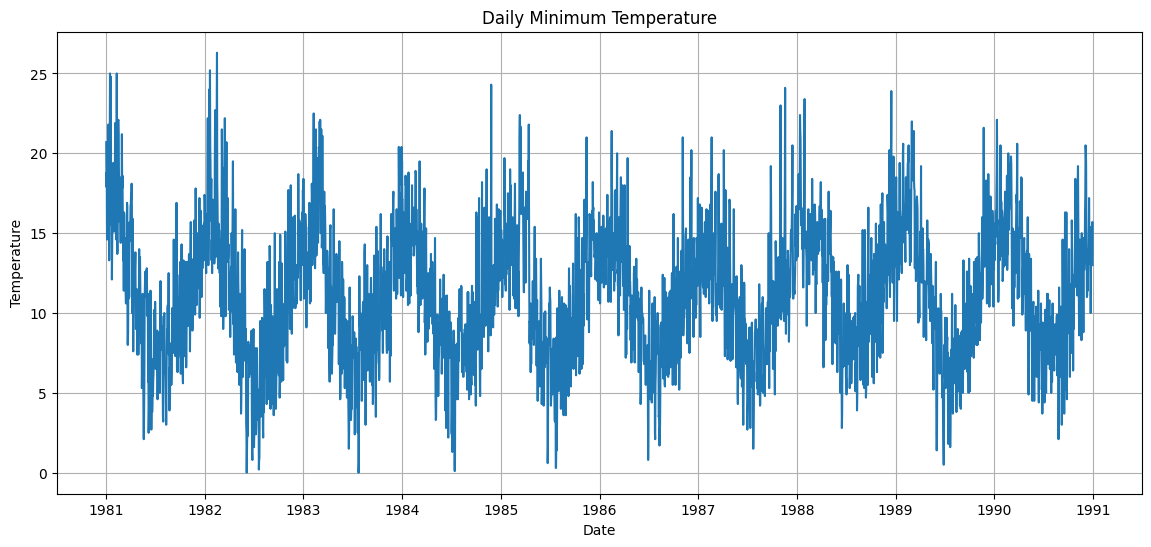

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df['Temp'])

plt.title("Daily Minimum Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

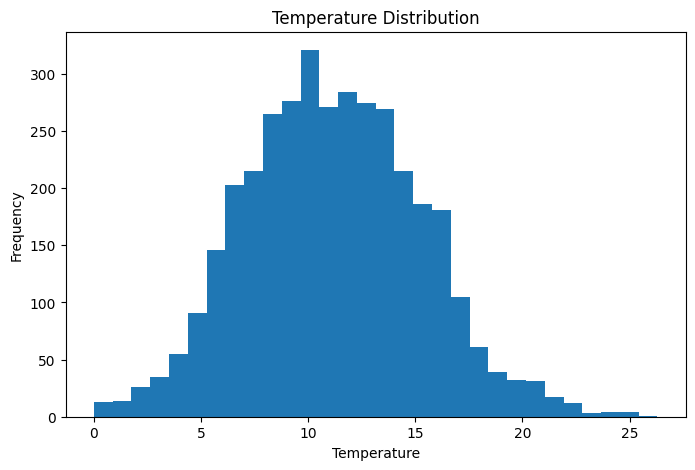

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['Temp'], bins=30)

plt.title("Temperature Distribution")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.show()

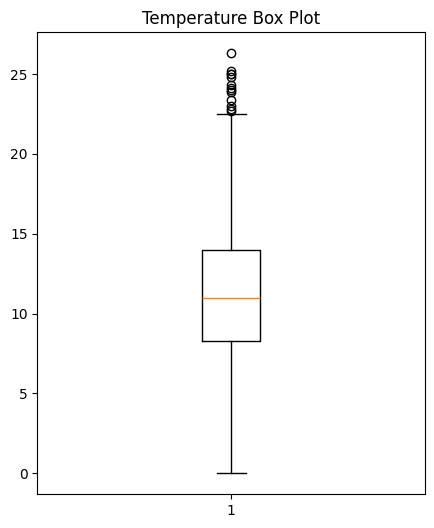

In [12]:
plt.figure(figsize=(5,6))

plt.boxplot(df['Temp'])

plt.title("Temperature Box Plot")

plt.show()

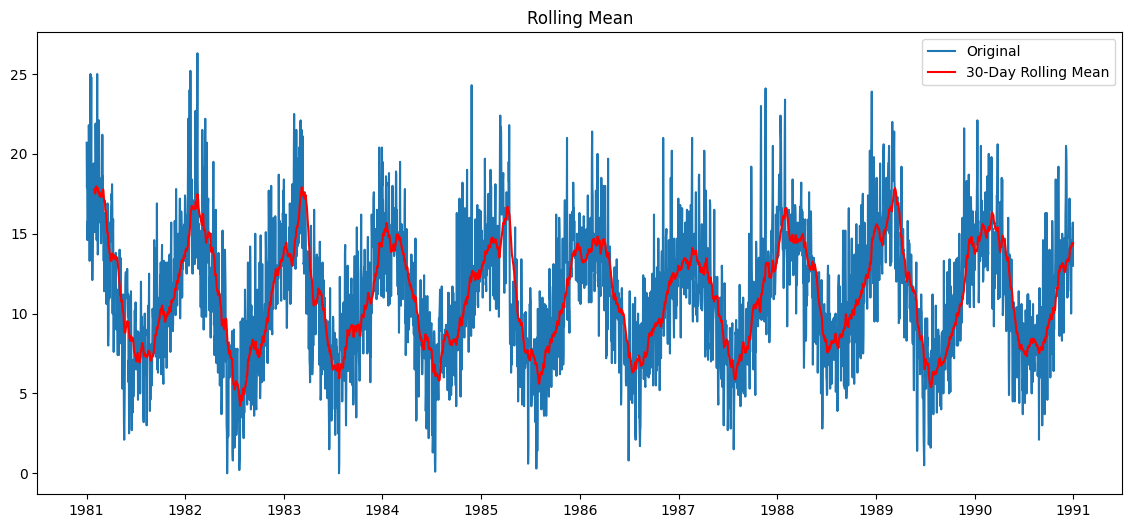

In [13]:
rolling_mean = df['Temp'].rolling(window=30).mean()

plt.figure(figsize=(14,6))

plt.plot(df['Temp'], label='Original')

plt.plot(rolling_mean, color='red', label='30-Day Rolling Mean')

plt.legend()

plt.title("Rolling Mean")

plt.show()

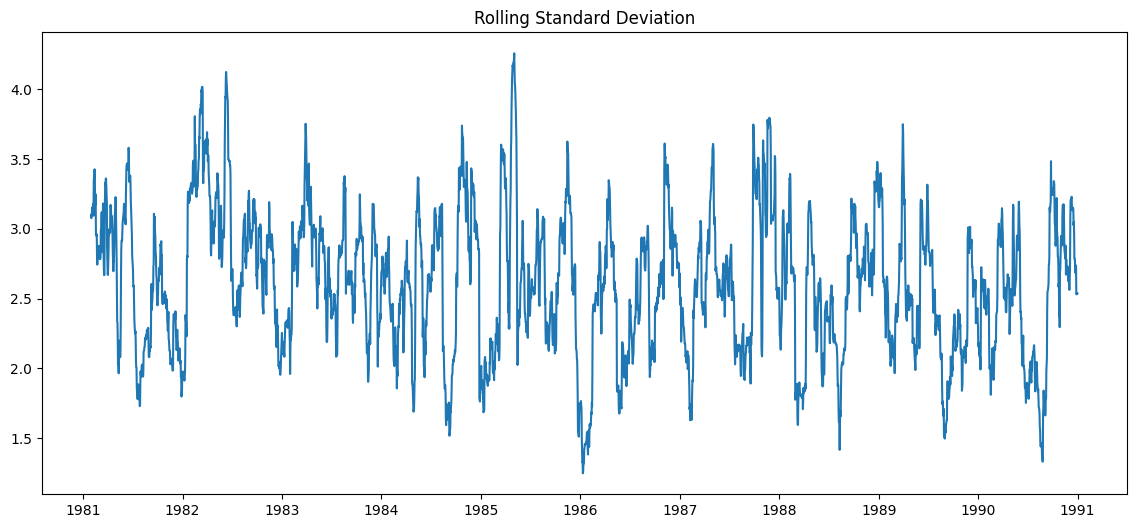

In [14]:
rolling_std = df['Temp'].rolling(window=30).std()

plt.figure(figsize=(14,6))

plt.plot(rolling_std)

plt.title("Rolling Standard Deviation")

plt.show()

In [15]:
result = adfuller(df['Temp'])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, value)

ADF Statistic : -4.444804924611687
p-value : 0.00024708263003611164

Critical Values
1% -3.4321532327220154
5% -2.862336767636517
10% -2.56719413172842


In [16]:
result = adfuller(df['Temp'])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, value)

ADF Statistic : -4.444804924611687
p-value : 0.00024708263003611164

Critical Values
1% -3.4321532327220154
5% -2.862336767636517
10% -2.56719413172842
